In [2]:
myimg=r"C:\Users\Windows\Desktop\Rumbaugh_e19_60X_targetoverview_projection_t0_B03_s0_w0_z0.tif"

C:\Users\Windows\AppData\Local\Temp\ipykernel_13928\784811241.py:21: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cleaned_mask = remove_small_objects(binary_mask, min_size=30)


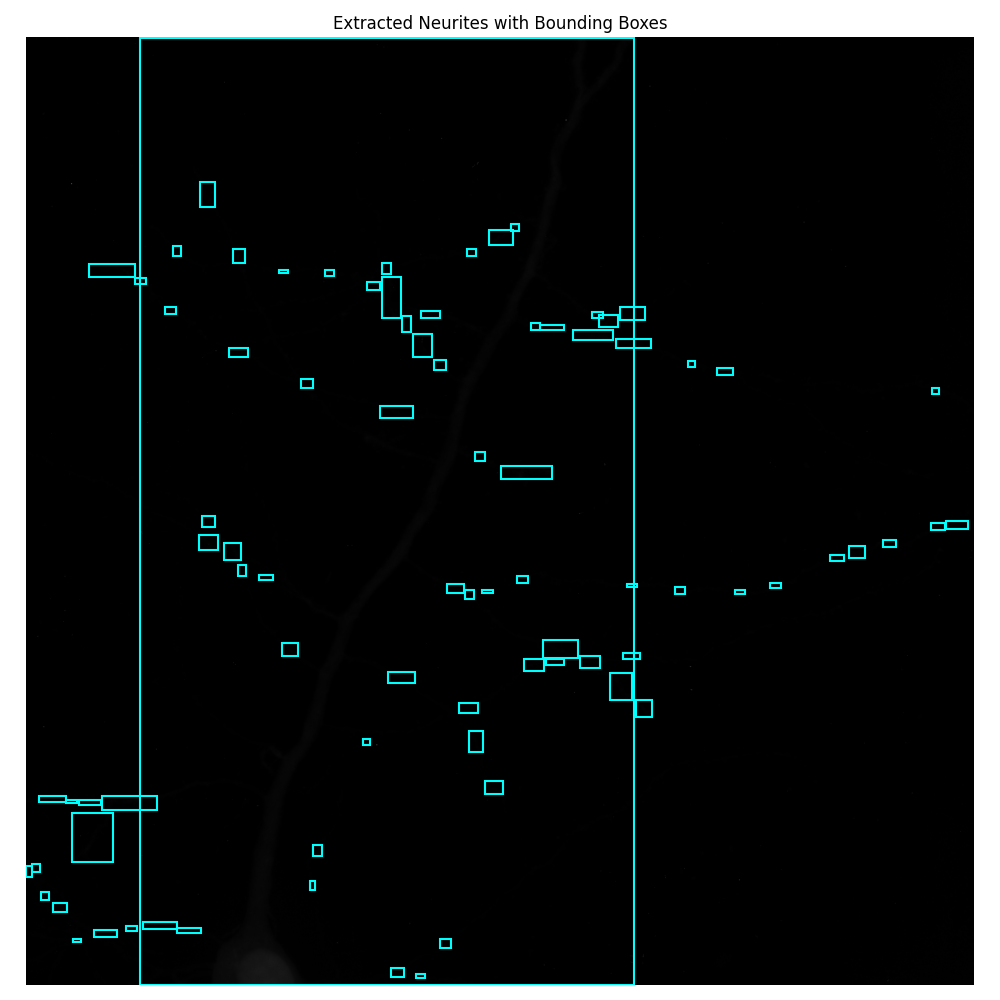

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, skeletonize
from skimage.util import img_as_float
from skimage.measure import label, regionprops
import tifffile

# 1. Load and process the TIFF image
image_raw = tifffile.imread(myimg)
image_slice = image_raw[0] if image_raw.ndim == 3 else image_raw

image_float = img_as_float(image_slice)
p2, p98 = np.percentile(image_float, (2, 98))
image_rescaled = np.clip((image_float - p2) / (p98 - p2), 0, 1)

# 2. Thresholding, cleaning, and skeletonization
thresh = threshold_otsu(image_rescaled)
binary_mask = image_rescaled > thresh
cleaned_mask = remove_small_objects(binary_mask, min_size=30)
skeleton = skeletonize(cleaned_mask)

# 3. Label components and get region properties (bounding boxes)
labeled_components = label(skeleton, connectivity=2)
regions = regionprops(labeled_components)

# 4. Plot original image with bounding boxes drawn around each extracted neurite
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(image_float, cmap="gray")

for region in regions:
    # Filter out tiny noise fragments based on area
    if region.area < 50:
        continue
        
    # Bounding box coordinates: (min_row, min_col, max_row, max_col)
    min_row, min_col, max_row, max_col = region.bbox
    height = max_row - min_row
    width = max_col - min_col
    
    # Create a Rectangle patch
    rect = patches.Rectangle(
        (min_col, min_row), width, height, 
        linewidth=1.5, edgecolor='cyan', facecolor='none'
    )
    ax.add_patch(rect)

ax.set_title("Extracted Neurites with Bounding Boxes")
ax.axis("off")
plt.tight_layout()
plt.show()